<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/11-Semana/Practica25_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autor: Juan Francisco Gámez Cortés.
Matricula: 261554

Última Modificación: 24 de octubre de 2025

# Práctica #25: Regresión con Datos Categóricos
# Objetivo:
** Regresión lineal con datos categóricos: Costos, Localidades y Salarios**

📌 Objetivos de la Práctica:
Al finalizar esta práctica, los estudiantes serán capaces de:

- Codificar variables categóricas usando one-hot encoding con K-1 para problemas de regresión
- Realizar AED
- Construir un modelo de regresión con variables dummy
- Interpretar los resultados de los coeficientes
- Analizar los resultados de los errores residuales
- Calcular el desempeño del modelo de regresión.

Problema: Se podría argumentar que el salario está relacionado con el costo de la educación. Por lo tanto, para analizar este argumentos veremos qué sucede cuando usamos las variables independientes cost y location.

In [ ]:
#Montar google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. Carga de datos

Carga el conjunto de datos college.csv, que está en campus virtual, en un dataframe. Elige de este conjunto las columnas salary (variable dependiente), cost(variable independiente - numérica) y location (variable independiente categórica).




In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

df = pd.read_csv('/content/drive/MyDrive/Unidad03/college.csv')
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        85 non-null     int64 
 1   name      85 non-null     object
 2   salary    85 non-null     int64 
 3   cost      85 non-null     int64 
 4   public    85 non-null     object
 5   location  85 non-null     object
dtypes: int64(3), object(3)
memory usage: 4.1+ KB
None


Realiza lo siguiente:

*   Convierte si es necesario la variable location a tipo de dato categórico
*   Usa la instrucción describe() en las variables salary y cost
* Cuenta la cantidad de datos que hay por categoría en location
* Convierte la variable location usando one-hot encoding

In [20]:
# Convertir a categorico
df['location'] = df['location'].astype('category')
print(df.info())

# Resumen estadistico de salary y cost
print(df[['salary','cost']].describe())

# Conteo de datos de Location
print(f"\nConteo de datos en Location:\n", df['location'].value_counts())

# Convertir location a One hot encoding
data = df.copy()

# One hot encoding K-1
print('\n')
print('Versión usando Scikit-Learn: K-1')
encoder = OneHotEncoder(sparse_output=False,drop='first')

encoded_data = encoder.fit_transform(data[['location']])

# Obtenet el nombre de la columna de interes
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['location']))

print(encoded_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   id        85 non-null     int64   
 1   name      85 non-null     object  
 2   salary    85 non-null     int64   
 3   cost      85 non-null     int64   
 4   public    85 non-null     object  
 5   location  85 non-null     category
dtypes: category(1), int64(3), object(2)
memory usage: 3.7+ KB
None
              salary           cost
count      85.000000      85.000000
mean    95898.823529  142434.470588
std     11937.121912   53913.064578
min     74900.000000   18260.000000
25%     87100.000000   84670.000000
50%     93200.000000  169200.000000
75%    105000.000000  188700.000000
max    123000.000000  227300.000000

Conteo de datos en Location:
 location
NE    25
W     21
S     20
MW    19
Name: count, dtype: int64


Versión usando Scikit-Learn: K-1
    location_NE  location_S  location_W
0        

# 2. Análisis Exploratorio de los Datos

Realiza un análisis exploratorio de los datos y discute lo que observas en cada gráfica.


*   Crea un histograma de la columna salary. Discute lo que observas





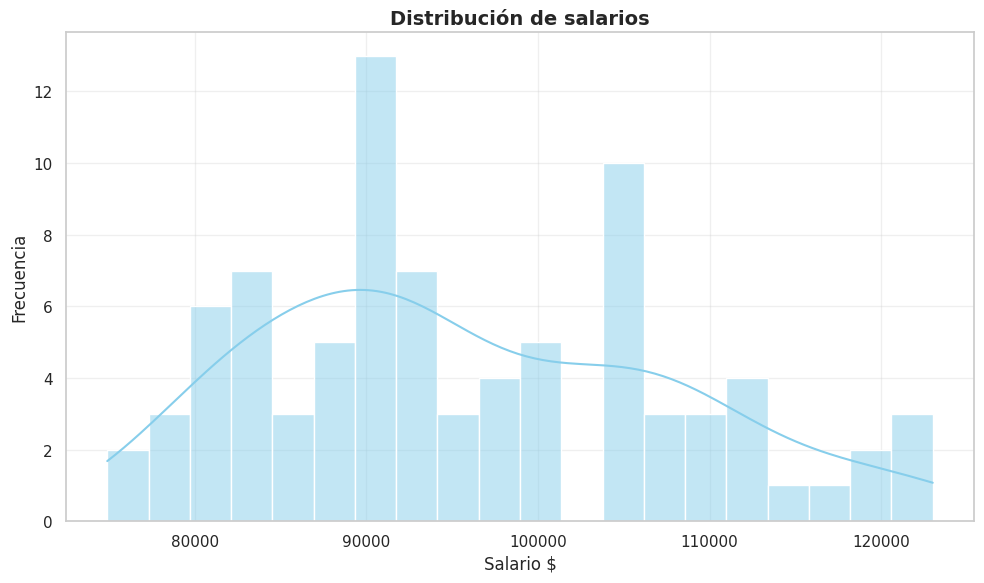

In [25]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))

sns.histplot(data=df, x='salary', bins=20, kde=True, color="skyblue")

plt.title("Distribución de salarios", fontsize=14, weight='bold')
plt.xlabel("Salario $", fontsize=12)
plt.ylabel("Frecuencia", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

`Se puede observar una distribución con sesgo y cola a la derecha, lo cual nos indica que no hay una distribución normal. Los datos se agrupan al lado izquierdo donde se concentran los salarios medios.`

* Crea un diagrama de dispersión de salary vs cost, considerando lo siguiente: para cada punto elegirás un color que represente la localidad en la que está el salario y el costo de la educación. Por lo tanto el diagrama de dispersión debería tener puntos en 4 colores distintos. Discute lo que observas


Text(0, 0.5, 'Salario $')

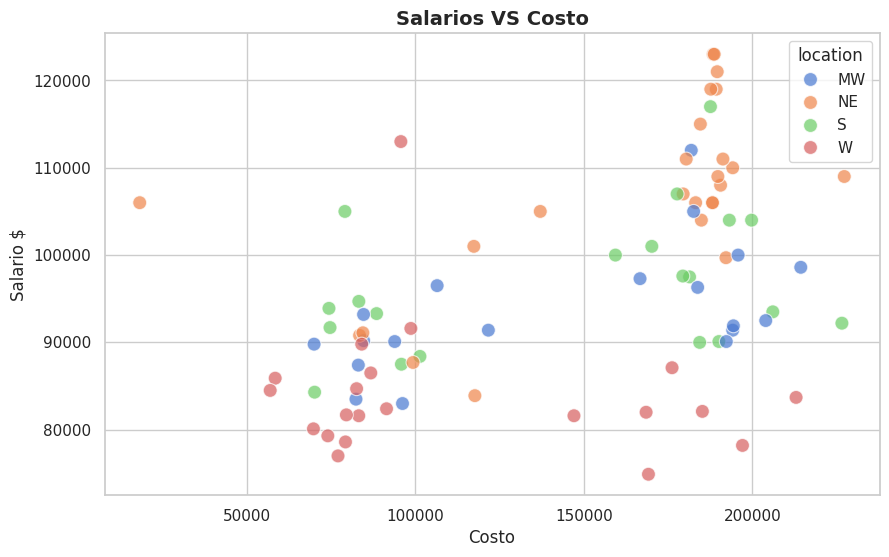

In [27]:
plt.figure(figsize=(10, 6))
scatter_plot = sns.scatterplot(data=df, x='cost', y='salary',hue='location', palette='muted', s=100, alpha=0.7)
plt.title("Salarios VS Costo", fontsize=14, weight='bold')
plt.xlabel("Costo", fontsize=12)
plt.ylabel("Salario $", fontsize=12)

`Se puede observar que tanto los costos como los salarios en W son menores respecto a las otras regiones, mientras que en NE se concentran mejores salarios`

* Emplea un boxplot para saber si hay diferencias en los costos según la ubicación, es decir, con boxplot deberás analizar la distribución de cost por localidad. Discute lo que observas

Text(0, 0.5, 'Costo')

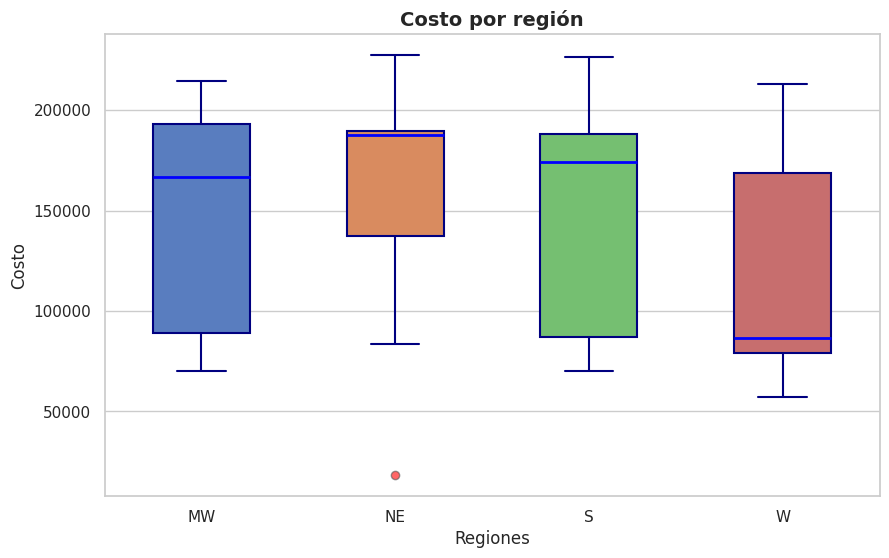

In [39]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='location',
    y='cost',
    palette='muted',
    hue='location',
    legend=False,
    width=0.5,
    flierprops={
        "marker": "o",
        "markersize": 6,
        "markerfacecolor": "red",
        "alpha": 0.6
    },
    boxprops={"edgecolor": "navy", "linewidth": 1.5},
    medianprops={"color": "blue", "linewidth": 2},
    whiskerprops={"color": "navy", "linewidth": 1.5},
    capprops={"color": "navy", "linewidth": 1.5}
)

plt.title("Costo por región", fontsize=14, weight='bold')
plt.xlabel("Regiones", fontsize=12)
plt.ylabel("Costo", fontsize=12)

`Observamos que las medianas son similares para las regiones MW y S, mientras que para la región W la mediana es muy baja respecto a las demás. Para la región NE se pueden observar outliers lo cual indica valores de costo excepcionalmente bajo.`

# 3. Construcción del modelo de regresión

- Construye el modelo de regresión usando los datos de salario, costo y location. Recuerda que esta última debe ser en su versión codificada con one-hot encoding.
- Imprime los coeficientes e interpreta qué significan cuando se sustituyen valores en costo, y location (versión codificada). Si no recuerdas cómo se hace esta interpretación consulta los videos.


In [43]:
from sklearn.linear_model import LinearRegression
# salary (variable dependiente) y location (variable independiente categórica).

df_multi =pd.read_csv('/content/drive/MyDrive/Unidad03/college.csv',usecols=['salary','cost','location'])

# Convertir location a categoría
df_multi['location'] = df_multi['location'].astype('category')

print('\nConjunto de Datos con la variable categórica codificada')
encoder = OneHotEncoder(sparse_output=False,drop='first')


encoded_data= encoder.fit_transform(df_multi[['location']])

# Crear un nuevo DataFrame con las columnas codificadas
encoded_df = pd.DataFrame(encoded_data, columns=encoder.get_feature_names_out(['location']))

# Concatenar el DataFrame codificado al DataFrame original
df_multi = pd.concat([df_multi, encoded_df], axis=1)

print(df_multi)


Conjunto de Datos con la variable categórica codificada
    salary    cost location  location_NE  location_S  location_W
0   119000  189300       NE          1.0         0.0         0.0
1   121000  189600       NE          1.0         0.0         0.0
2   123000  188400       NE          1.0         0.0         0.0
3   123000  188700       NE          1.0         0.0         0.0
4   110000  194200       NE          1.0         0.0         0.0
..     ...     ...      ...          ...         ...         ...
80   79300   74070        W          0.0         0.0         1.0
81   80100   69800        W          0.0         0.0         1.0
82   74900  169200        W          0.0         0.0         1.0
83   84500   56970        W          0.0         0.0         1.0
84   78200  197100        W          0.0         0.0         1.0

[85 rows x 6 columns]


In [47]:
# Modelo de regresión lineal
X = df_multi[['location_NE', 'location_S', 'location_W']]  # MW es categoría base
y = df_multi['cost']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


# Mostrar resultados
print("Coeficientes para Costo:")
print(f"Intercepto (MW): {model.intercept_:.2f}")
print(f"location_NE: {model.coef_[0]:.2f}")
print(f"location_S : {model.coef_[1]:.2f}")
print(f"location_W : {model.coef_[2]:.2f}")

Coeficientes para Costo:
Intercepto (MW): 143859.47
location_NE: 19175.33
location_S : 2312.03
location_W : -30797.57


`El modelo de regresión lineal:`

costo = 143859.47 + 19175.33 * location_NE + 2312.03 * location_S - 30797.57 * location_S

Interpretación de los resultados:

Costo = >

Medio Oeste = 143859.47

Noreste = 163034.80

Sur = 146171.50

Oeste= 113061.90



# 4. Análisis de Residuos

- Construyen una visualización de predicciones (salario estimado) vs valores reales (salario real).
- Crea una gráfica de los errores residuales. Discute lo que observas

Coeficientes para Salario:
Intercepto (MW): 93694.74
location_NE: 13193.26
location_S : 2940.26
location_W : -9585.21


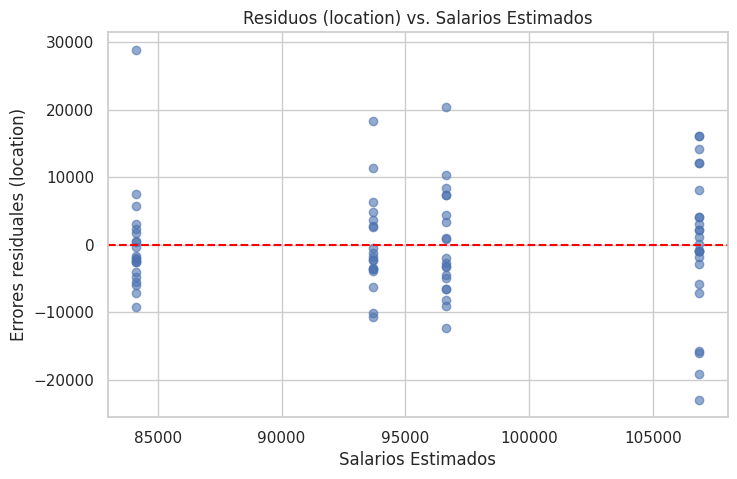

In [48]:
# Modelo de regresión lineal
X = df_multi[['location_NE', 'location_S', 'location_W']]  # MW es categoría base
y = df_multi['salary']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


# Mostrar resultados
print("Coeficientes para Salario:")
print(f"Intercepto (MW): {model.intercept_:.2f}")
print(f"location_NE: {model.coef_[0]:.2f}")
print(f"location_S : {model.coef_[1]:.2f}")
print(f"location_W : {model.coef_[2]:.2f}")

residuals= y-y_pred
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Salarios Estimados")
plt.ylabel("Errores residuales (location)")
plt.title("Residuos (location) vs. Salarios Estimados")
plt.grid(True)
plt.show()

`Análisis de errores residuales`
Observamos el el modelo esta generado con cuatro valores diferentes que representan las regiones.
Dentro de cada categoría el modelo predice un valor único. La dispersión de los salarios más bajos es menor, mientras que para salarios altos la variabilidad es mayor mostrando una dispersión más alta.
El histograma nos indica que casi se presenta una simetria respecto al cero, errores sesgados en ambas direcciones y algunos residuos son grandes



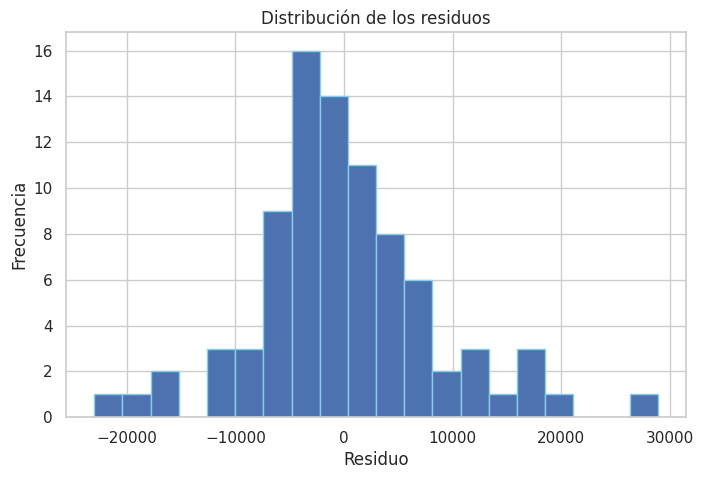

In [49]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=20, edgecolor='skyblue')
plt.title("Distribución de los residuos")
plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

# 5. Evalúa el modelo

- Calcula el MSE del modelo construido. Recuerda que usas el propio conjunto de datos (No hablamos nada de entrenamiento y test).
- Calcula el R² Score

Discute estos resultados obtenidos.

In [54]:
from sklearn.metrics import mean_squared_error, r2_score, max_error
# Evaluación
error_max = max_error(y,y_pred)
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)
print("\nEvaluación del modelo:")

print(f"Error absoluto máximo: {error_max:.2f}")
print(f"Error cuadrático medio (MSE): {mse:.2f}")
print(f"R² (R-squared): {r2:.4f}")


Evaluación del modelo:
Error absoluto máximo: 28890.48
Error cuadrático medio (MSE): 69748699.63
R² (R-squared): 0.5047


`Evaluación del modelo`

El salario predicho tiene un error absoluto máximo del modelo es de 28890.48
El MSE elimina los valores negativos de las predicciones, además le da más peso a los errores grandes que a los pequeños.

El R-squared o coeficiente de determinación sirve para evaluar que tan bien se ajusta el modelo a nuestros datos, en nuestro caso el valor de 0.5047 nos indica que el modelo tiene una variabilidad del 50.47%


# 6. Realiza un análisis de varianza con stastmodel

Consulta esto aquí https://www.statsmodels.org/dev/examples/notebooks/generated/variance_components.html

In [57]:
import statsmodels.api as sm

response = "salary"   # variable respuesta
covariate = "cost"    # covariable (opcional)
group = "location"    # agrupamiento (efecto aleatorio)

# -----------------------------------------
# A) MODELO 1: Intercepto aleatorio por Location (sin covariables)
#   y ~ 1 + (1 | Location)
# -----------------------------------------
print("\n--- MODELO A: Intercepto aleatorio por Location (sin covariables) ---")
model_a = sm.MixedLM.from_formula(f"{response} ~ 1", groups=group, re_formula="1", data=df)
res_a = model_a.fit(reml=True)
print(res_a.summary())

# Extraer componentes: varianza de Location y varianza residual (scale)
# Nombres pueden variar según versión; buscamos heurísticamente
def extract_vcomps(result):
    comps = {}
    try:
        comps['residual'] = float(result.scale)
    except Exception:
        comps['residual'] = np.nan
    # buscar en params
    params = getattr(result, "params", None)
    if params is not None:
        for k, v in params.items():
            kstr = str(k)
            # heurística: si contiene 'Var' o el nombre de group, lo tomamos
            if ("Var" in kstr) or (group in kstr) or ("vc" in kstr) or ("re" in kstr):
                try:
                    comps[kstr] = float(v)
                except Exception:
                    pass
    # fallback: revisar vcomp si existe (array)
    if hasattr(result, "vcomp") and result.vcomp is not None:
        comps['vcomp_array'] = np.array(result.vcomp)
    return comps

v_a = extract_vcomps(res_a)
print("\nComponentes estimados (MODELO A):")
for k, val in v_a.items():
    print(f"  {k}: {val}")

# Calcular ICC aproximado (proporción de varianza debida a Location)
if 'residual' in v_a and len([k for k in v_a.keys() if k!='residual' and k!='vcomp_array'])>=1:
    vars_components = [v_a[k] for k in v_a.keys() if k not in ('residual','vcomp_array')]
    total = sum(vars_components) + v_a['residual']
    print("\nProporciones de varianza (ICC-like) MODELO A:")
    for k in [k for k in v_a.keys() if k not in ('residual','vcomp_array')]:
        print(f"  {k}: {v_a[k]/total:.3f}")
    print(f"  residual: {v_a['residual']/total:.3f}")
else:
    print("\nNo fue posible calcular ICC automáticamente para MODELO A (nombres no detectados).")

# -----------------------------------------
# B) MODELO 2: Intercepto aleatorio por Location + 'Cost' como covariable fija
#   Salary ~ Cost + (1 | Location)
# -----------------------------------------
print("\n--- MODELO B: Intercepto aleatorio por Location + Cost como covariable fija ---")
model_b = sm.MixedLM.from_formula(f"{response} ~ {covariate}", groups=group, re_formula="1", data=df)
res_b = model_b.fit(reml=True)
print(res_b.summary())

v_b = extract_vcomps(res_b)
print("\nComponentes estimados (MODELO B):")
for k, val in v_b.items():
    print(f"  {k}: {val}")

    # Proporciones ICC-like para modelo con covariable
if 'residual' in v_b and len([k for k in v_b.keys() if k!='residual' and k!='vcomp_array'])>=1:
    vars_components = [v_b[k] for k in v_b.keys() if k not in ('residual','vcomp_array')]
    total = sum(vars_components) + v_b['residual']
    print("\nProporciones de varianza (ICC-like) MODELO B:")
    for k in [k for k in v_b.keys() if k not in ('residual','vcomp_array')]:
        print(f"  {k}: {v_b[k]/total:.3f}")
    print(f"  residual: {v_b['residual']/total:.3f}")




--- MODELO A: Intercepto aleatorio por Location (sin covariables) ---
               Mixed Linear Model Regression Results
Model:               MixedLM    Dependent Variable:    salary       
No. Observations:    85         Method:                REML         
No. Groups:          4          Scale:                 73184780.8511
Min. group size:     19         Log-Likelihood:        -886.8277    
Max. group size:     25         Converged:             Yes          
Mean group size:     21.2                                           
--------------------------------------------------------------------
                Coef.     Std.Err.   z    P>|z|   [0.025    0.975]  
--------------------------------------------------------------------
Intercept       95351.181 4703.669 20.272 0.000 86132.160 104570.202
location Var 85017438.469 8573.745                                  


Componentes estimados (MODELO A):
  residual: 73184780.85106398
  location Var: 1.1616819437128825
  vcomp_array: [

`Análisis de componentes de varianza`

La varianza por regiones es de 85,017,438, las proporciones de varianzas ICC like indican que la variación de salarios no proviene de la región, por lo cual la variable location no explica diferencias significativas en los salarios.
